In [2]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import joblib

df = pd.read_csv('high_risk_pregnancy_realistic_2000 (1).csv')

In [3]:
x_train_smote = joblib.load('x_train_smote.pkl')
y_train_smote = joblib.load('y_train_smote.pkl')
x_test_scaled = joblib.load('x_test_scaled.pkl')
y_test        = joblib.load('y_test.pkl')

In [36]:
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=20,
    eval_metric='logloss',
    use_label_encoder=False
)

In [37]:
xgb_model.fit(x_train_smote, y_train_smote)

c:\Users\kriti\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:03:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [38]:
xgb_pred = xgb_model.predict(x_test_scaled)
xgb_prob = xgb_model.predict_proba(x_test_scaled)[:, 1]
print(xgb_prob)

[3.86901647e-02 1.39795640e-03 1.43760713e-02 3.87613103e-02
 8.10330689e-01 3.82647440e-02 1.43799428e-02 4.42248024e-02
 5.37696183e-01 2.17562332e-03 6.13041341e-01 2.71994948e-01
 7.14002103e-02 2.06213836e-02 8.59141946e-02 4.76694433e-03
 1.56428083e-03 7.77840436e-01 3.17927706e-03 7.03492761e-03
 1.24904856e-01 2.27102831e-01 2.89411068e-01 9.88115184e-03
 8.03358138e-01 1.55761451e-01 4.81350627e-03 8.47936049e-03
 1.20431088e-01 1.05166538e-02 3.49143416e-01 4.67109829e-01
 7.80463731e-03 1.18288435e-01 7.16556907e-02 2.53713294e-03
 8.56471815e-05 3.75405856e-04 3.18767726e-01 3.67821157e-02
 3.28766793e-01 2.22600438e-03 1.08225539e-03 1.38553321e-01
 2.69220024e-02 1.72472908e-03 8.35664719e-02 6.14801049e-02
 1.71945174e-03 7.75385322e-03 1.24398107e-03 1.03039027e-03
 4.51798987e-04 3.56051326e-01 1.64955810e-01 3.07534356e-02
 6.08482920e-02 4.15203452e-01 1.86507717e-01 6.31634239e-03
 2.03887190e-04 7.93606043e-03 5.18722460e-03 2.91836876e-02
 1.11756905e-03 1.725157

In [39]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", round(xgb_accuracy, 4))

XGBoost Accuracy: 0.8045


In [40]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.85      0.92      0.89       330
           1       0.39      0.23      0.29        69

    accuracy                           0.80       399
   macro avg       0.62      0.58      0.59       399
weighted avg       0.77      0.80      0.78       399



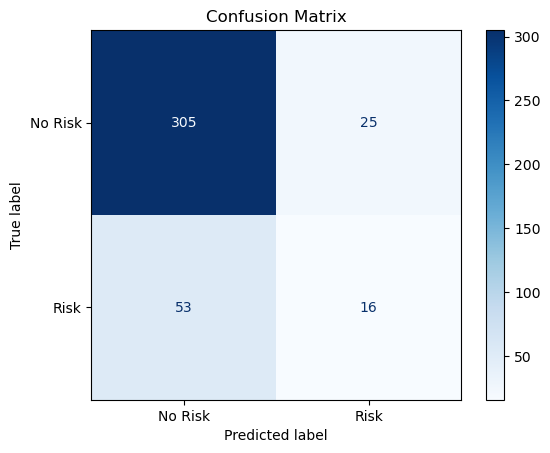

In [41]:
ConfusionMatrixDisplay.from_predictions(
    y_test, xgb_pred,
    display_labels=['No Risk', 'Risk'],
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.show()

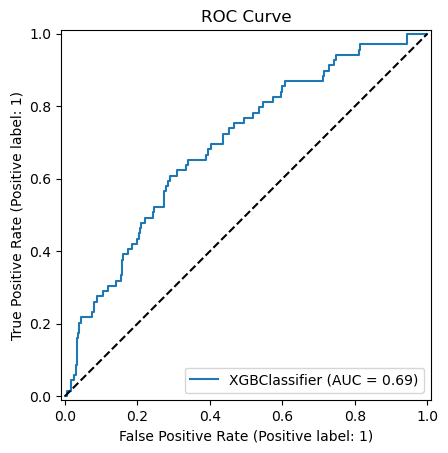

In [42]:
RocCurveDisplay.from_estimator(xgb_model, x_test_scaled, y_test)
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.show()

In [43]:
print('ROC-AUC Score:', roc_auc_score(y_test, xgb_prob).round(4))

ROC-AUC Score: 0.6947


In [44]:
X = df.drop('risk_class', axis=1)
feature_names = X.columns
n_importances = len(xgb_model.feature_importances_)

print("df shape:", df.shape)
print("x_train_smote shape:", x_train_smote.shape)

df shape: (2000, 24)
x_train_smote shape: (2732, 28)


In [45]:
if len(feature_names) == n_importances:
    labels = feature_names
else:
    labels = [f"feature_{i}" for i in range(n_importances)]

feature_importance = pd.DataFrame({
    "Feature": labels,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
print(feature_importance.to_string(index=False))

   Feature  Importance
feature_24    0.077848
feature_21    0.077613
feature_25    0.065860
feature_19    0.061185
feature_22    0.048843
feature_27    0.046816
feature_13    0.041632
feature_20    0.040889
feature_23    0.040538
 feature_9    0.040286
feature_12    0.039181
 feature_1    0.038207
feature_17    0.037792
 feature_4    0.034852
feature_26    0.029037
feature_18    0.027959
 feature_0    0.027579
 feature_3    0.027266
feature_10    0.027197
 feature_6    0.027094
feature_14    0.027079
feature_11    0.022948
 feature_8    0.021278
 feature_7    0.018797
feature_16    0.018183
 feature_2    0.017243
feature_15    0.016799
 feature_5    0.000000


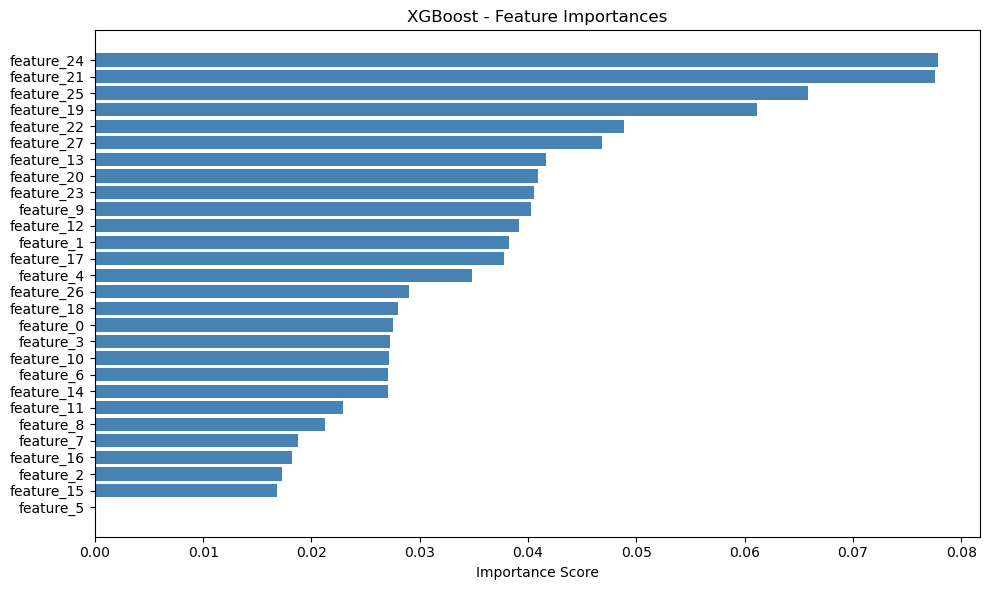

In [46]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("XGBoost - Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [47]:
train_pred = xgb_model.predict(x_train_smote)
train_accuracy = accuracy_score(y_train_smote, train_pred)
print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy :", round(xgb_accuracy, 4))

Train Accuracy: 1.0
Test Accuracy : 0.8045


In [48]:
precision = precision_score(y_test, xgb_pred)
recall    = recall_score(y_test, xgb_pred)
f1        = f1_score(y_test, xgb_pred)

print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Precision: 0.3902
Recall   : 0.2319
F1 Score : 0.2909


In [49]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=20, eval_metric='logloss', use_label_encoder=False),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(x_train_smote, y_train_smote)

c:\Users\kriti\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:03:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [50]:
print("Best Params:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300}


In [51]:
best_pred = best_model.predict(x_test_scaled)
best_prob = best_model.predict_proba(x_test_scaled)[:, 1]
print("Best Model Accuracy:", round(accuracy_score(y_test, best_pred), 4))
print("Best Model ROC-AUC :", roc_auc_score(y_test, best_prob).round(4))

Best Model Accuracy: 0.817
Best Model ROC-AUC : 0.6961


In [52]:
cv_scores = cross_val_score(xgb_model, x_train_smote, y_train_smote, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores.round(4))
print("Mean:", cv_scores.mean().round(4), "| Std dev:", cv_scores.std().round(4))

c:\Users\kriti\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:03:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\kriti\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:03:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\kriti\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:03:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\kriti\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:03:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

CV ROC-AUC Scores: [0.9124 0.9846 0.9862 0.9878 0.986 ]
Mean: 0.9714 | Std dev: 0.0295


In [53]:
joblib.dump(xgb_model, 'xgboost_model.pkl')
print("Model saved.")

Model saved.
